# Stage 6 — The Multipole Graph Neural Operator (MGNO)

GNO's radius truncation captures local interactions cheaply, but a *single* fixed radius cannot cheaply capture **long-range** interactions — covering the whole domain with one radius reintroduces $O(J^2)$ cost. The paper's multipole idea (Section 4.3, inspired by the classical Fast Multipole Method) resolves this with a **hierarchy of grids** at decreasing resolution: long-range interactions happen on a *coarse* level, where there are few enough points that dense (near-global) connectivity stays cheap.

We implement a simplified, two-level version of this idea in `neural_operators/models/mgno.py`:

1. **Fine-to-fine**: ordinary radius-truncated GNO message passing at full resolution — captures local/near-field interactions.
2. **Restrict** (fine → coarse): fine-level features are aggregated onto a much coarser point set (every `coarse_stride`-th grid point in each direction) via a radius-truncated kernel — a learned analogue of multigrid *restriction*.
3. **Coarse-to-coarse**: message passing among coarse points with a **large** radius that makes the coarse graph effectively fully connected. Because there are few coarse points, this dense computation stays cheap — this is exactly what lets long-range/far-field interactions be captured without paying $O(J^2)$ at the fine level.
4. **Prolong** (coarse → fine): the processed coarse features are broadcast back down to the fine points (radius-truncated kernel, analogous to multigrid *prolongation*) and added to the fine-to-fine output.

Every step reuses the same message-passing building block as GNO (a learned per-edge kernel matrix + mean aggregation), just applied across four different edge sets instead of one.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath(".."))

import torch
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

from neural_operators.models.mgno import MGNO2d
from neural_operators.utils import train_model, count_params, measure_inference_time, RelativeL2Loss

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [2]:
cache = torch.load("../data_cache/navier_stokes_64.pt")
a_data, u_data = cache["a"], cache["u"]
n_train, n_test = cache["n_train"], cache["n_test"]

a_mean, a_std = a_data[:n_train].mean(), a_data[:n_train].std()
u_mean, u_std = u_data[:n_train].mean(), u_data[:n_train].std()
a_norm = (a_data - a_mean) / a_std
u_norm = (u_data - u_mean) / u_std

train_ds = TensorDataset(a_norm[:n_train], u_norm[:n_train])
test_ds = TensorDataset(a_norm[n_train:], u_norm[n_train:])
train_loader = DataLoader(train_ds, batch_size=20, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=20, shuffle=False)

In [3]:
model = MGNO2d(
    in_channels=3, out_channels=1, width=16, n_layers=4,
    fine_radius=0.08, restrict_radius=0.12, coarse_stride=4, n_fine_subsample=384,
)
print("trainable parameters:", count_params(model))

# build+cache the multi-scale graph once up front (excluded from epoch-0 timing)
with torch.no_grad():
    model.to(device)(torch.zeros(1, 64, 64, device=device))
g = model._get_graph(64, 64, device)
print(f"n_fine={g['n_fine']}, n_coarse={g['n_coarse']}")
print(f"fine edges={g['fine_edge_index'].shape[1]}, restrict edges={g['restrict_edge_index'].shape[1]}, "
      f"coarse edges={g['coarse_edge_index'].shape[1]}, prolong edges={g['prolong_edge_index'].shape[1]}")

history = train_model(model, train_loader, test_loader, epochs=80, lr=2e-3, device=device, verbose_every=10)

trainable parameters: 158081


n_fine=4096, n_coarse=256
fine edges=29256, restrict edges=39356, coarse edges=65536, prolong edges=39356


epoch    0 | train rel-L2 0.8204 | test rel-L2 0.5327 | 3.9s


epoch   10 | train rel-L2 0.1206 | test rel-L2 0.1175 | 40.2s


epoch   20 | train rel-L2 0.0893 | test rel-L2 0.0909 | 77.2s


...

epoch   40 | train rel-L2 0.0711 | test rel-L2 0.0730 | 151.4s


epoch   50 | train rel-L2 0.0581 | test rel-L2 0.0599 | 188.6s


epoch   60 | train rel-L2 0.0550 | test rel-L2 0.0578 | 225.9s


epoch   70 | train rel-L2 0.0539 | test rel-L2 0.0564 | 263.2s


epoch   79 | train rel-L2 0.0537 | test rel-L2 0.0563 | 296.8s


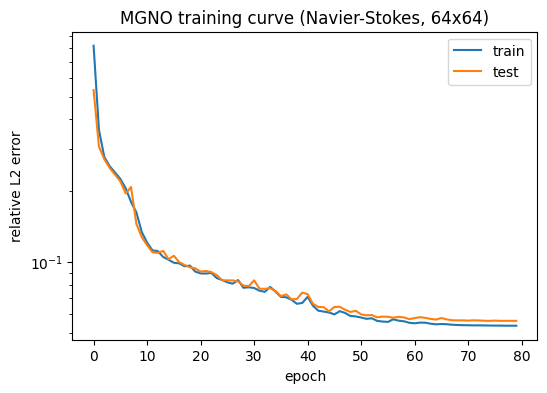

final test relative L2 error: 0.0563


In [4]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["test_loss"], label="test")
plt.xlabel("epoch")
plt.ylabel("relative L2 error")
plt.yscale("log")
plt.legend()
plt.title("MGNO training curve (Navier-Stokes, 64x64)")
plt.show()
print(f"final test relative L2 error: {history['test_loss'][-1]:.4f}")

## Qualitative check

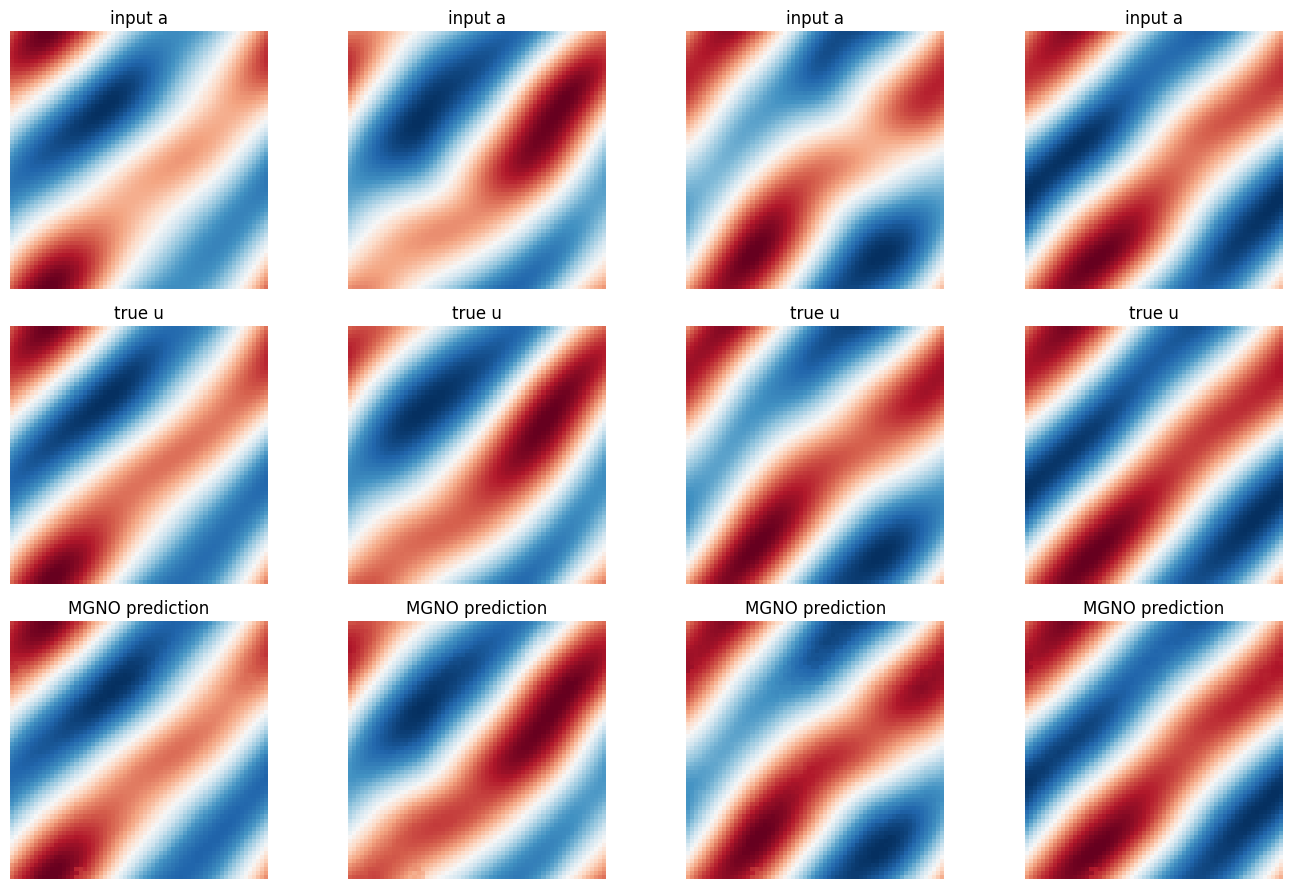

In [5]:
model.eval()
with torch.no_grad():
    x_sample, y_sample = next(iter(test_loader))
    pred = model(x_sample.to(device)).cpu()

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for i in range(4):
    axes[0, i].imshow(x_sample[i] * a_std + a_mean, cmap="RdBu_r"); axes[0, i].set_title("input a"); axes[0, i].axis("off")
    axes[1, i].imshow(y_sample[i] * u_std + u_mean, cmap="RdBu_r"); axes[1, i].set_title("true u"); axes[1, i].axis("off")
    axes[2, i].imshow(pred[i] * u_std + u_mean, cmap="RdBu_r"); axes[2, i].set_title("MGNO prediction"); axes[2, i].axis("off")
plt.tight_layout()
plt.show()

## Discretization invariance

resolution   32x32   -> relative L2 error: 0.0686


resolution   64x64   -> relative L2 error: 0.0563


resolution   96x96   -> relative L2 error: 0.0572


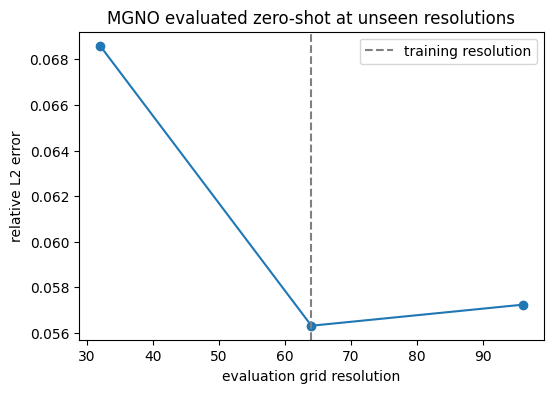

In [6]:
from neural_operators.data.grf import GaussianRF2d
from neural_operators.data.navier_stokes_2d import solve_navier_stokes_2d, default_forcing

def make_hr_test_set(n_hr, n_samples=20, seed=123):
    torch.manual_seed(seed)
    grf_hr = GaussianRF2d(n_hr, alpha=2.5, tau=7.0, device=device)
    f_hr = default_forcing(n_hr, device=device)
    w0 = grf_hr.sample(n_samples)
    burnin, _ = solve_navier_stokes_2d(w0, f_hr, visc=1e-3, T=4.5, delta_t=1e-3, record_steps=1)
    a = burnin[..., -1]
    traj, _ = solve_navier_stokes_2d(a, f_hr, visc=1e-3, T=2.0, delta_t=1e-3, record_steps=1)
    return a.cpu(), traj[..., -1].cpu()

resolutions = [32, 64, 96]
errors = []
loss_fn = RelativeL2Loss()
for res in resolutions:
    a_res, u_res = make_hr_test_set(res, n_samples=20)
    a_res_n = (a_res - a_mean) / a_std
    u_res_n = (u_res - u_mean) / u_std
    with torch.no_grad():
        pred = model(a_res_n.to(device))
    err = loss_fn(pred.cpu(), u_res_n).item()
    errors.append(err)
    print(f"resolution {res:>4d}x{res:<4d} -> relative L2 error: {err:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(resolutions, errors, marker="o")
plt.axvline(64, color="gray", linestyle="--", label="training resolution")
plt.xlabel("evaluation grid resolution")
plt.ylabel("relative L2 error")
plt.title("MGNO evaluated zero-shot at unseen resolutions")
plt.legend()
plt.show()

In [7]:
x_batch = a_norm[:20]
mgno_time = measure_inference_time(model, x_batch, device=device)
print(f"MGNO inference time per sample: {mgno_time*1000:.3f} ms")

os.makedirs("../results", exist_ok=True)
torch.save(model.state_dict(), "../results/mgno_navier_stokes.pt")
with open("../results/mgno_summary.json", "w") as fp:
    json.dump({
        "params": count_params(model),
        "final_test_rel_l2": history["test_loss"][-1],
        "inference_time_s": mgno_time,
        "discretization_invariance": dict(zip(resolutions, errors)),
    }, fp, indent=2)
print("saved model + summary to ../results/")

MGNO inference time per sample: 128.902 ms
saved model + summary to ../results/


## Next step

`06_compare_results.ipynb` collects the saved summaries from all four architectures (FNO, GNO, LNO, MGNO) into a single paper-style comparison table and plot.